# Load modules

In [251]:
from glob import glob
from datetime import datetime 
import xarray as xr 
import numpy as np 
from scipy.interpolate import griddata
import seawater as sw

#For plotting
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt 
from matplotlib.ticker import MaxNLocator
from matplotlib.colors import BoundaryNorm
from matplotlib.colors import ListedColormap
import cmocean 
from shapely.geometry.polygon import Polygon

# For derivative of SWOT SSH, we use the functions detailed in 
# Tranchant, Y.-T., Legresy, B., Foppert, A., Pena-Molino, B., & Phillips, H. (2025). 
# SWOT reveals fine-scale balanced motions driving near-surface currents and dispersion 
# in the Antarctic Circumpolar Current. Earth and Space Science, 12, e2025EA004248. 
# https://doi.org/10.1029/2025EA004248
# They can be downloaded here: https://github.com/treden/swotdiag

import sys
sys.path.insert(1, '/Users/solangecoadou/Desktop/Desktop/Thesis/Chapter_3/SwotDiag/')
from SwotDiag.diagnosis import *

import functions

# Define directories

In [252]:
main_path = '/Users/solangecoadou/Desktop/Desktop/Thesis/Data_QUICCHE/'
path_save = '/Users/solangecoadou/Desktop/Desktop/Thesis/Figure_QUICCHE/submission/'
data_dir_SSH = main_path + 'DUACS_new/'
swot_dir = main_path + 'SWOT_last_version/'

# Define period and region of interest

In [253]:
start = datetime(2023, 3, 10)
stop = datetime(2023, 7, 10)

pos_west, pos_east, pos_south, pos_north  = 10, 25, -42, -30.5  #Reset the area

# Load data

In [254]:
### DUACS
filenames = [x for x in glob(data_dir_SSH+'*.nc')] 
filenames.sort()
ds_ssh = xr.open_mfdataset(filenames).sel(time=slice(np.datetime64(start), np.datetime64(stop)), longitude=slice(pos_west, pos_east), latitude=slice(pos_south, pos_north)) 

### SWOT
file_swot = [x for x in glob(swot_dir+'*.nc')] 
file_swot.sort()

### SST
file_SST = main_path + 'METOFFICE-GLO-SST-L4-NRT-OBS-SST-V2_1706891014112.nc'
ds_sst = xr.open_dataset(file_SST).sel(time=slice(np.datetime64(start), np.datetime64(stop)))

# Set parameters for the plot

In [237]:
#Dates of interest
list_days = ds_ssh.time.data 
date_SST = 29
date_zoom_1 = 19
date_zoom_2 = 44
print('Date SST map: ' + str(list_days[date_SST])[:10])
print('Date zoom 1: ' + str(list_days[date_zoom_1])[:10])
print('Date zoom 2: ' + str(list_days[date_zoom_2])[:10])

ft = 23

##Define colorbars

    #SSH
Tinc_SSH = np.arange(-0.2,1.2, 0.1)
cmap1 = cmocean.tools.crop(cmocean.cm.delta, vmin=Tinc_SSH[0], vmax=Tinc_SSH[-1], pivot=0)
newcolors = cmap1(np.linspace(0, 1, len(Tinc_SSH)))
pos = np.where(Tinc_SSH>=0)[0][0]
white = np.array([1, 1, 1, 1])
newcolors[pos-1:pos+1, :] = white
cmap_SSH = ListedColormap(newcolors)
levels = MaxNLocator(nbins=len(Tinc_SSH)).tick_values(Tinc_SSH[0], Tinc_SSH[-1])
norm_SSH = BoundaryNorm(levels, ncolors=cmap_SSH.N, clip=True) 

    #SST
Tinc_SST = np.arange(18,22, 0.1)
cmap_SST = cmocean.cm.thermal
levels = MaxNLocator(nbins=len(Tinc_SST)).tick_values(Tinc_SST[0], Tinc_SST[-1])
norm_SST = BoundaryNorm(levels, ncolors=cmap_SST.N, clip=True)

    #Velocity
cmap1 = plt.get_cmap('Reds')
Tinc_V=np.arange(0,2.55, 0.1)
newcolors = cmap1(np.linspace(0, 1, len(Tinc_V)))
pos = np.where(Tinc_V>=0)[0][0]
white = np.array([1, 1, 1, 1])
newcolors[pos:pos+1, :] = white
cmap_V = ListedColormap(newcolors)
levels2 = MaxNLocator(nbins=len(Tinc_V)).tick_values(Tinc_V[0], Tinc_V[-1])
norm_V = BoundaryNorm(levels2, ncolors=cmap_V.N, clip=True)

    #Epsilon
Tinc_eps=np.arange(-1.2,1.2, 0.1)
cmap1 = cmocean.tools.crop(cmocean.cm.balance, vmin=Tinc_eps[0], vmax=Tinc_eps[-1], pivot=0)
newcolors = cmap1(np.linspace(0, 1, len(Tinc_eps)))
pos = np.where(Tinc_eps>=0)[0][0]
white = np.array([1, 1, 1, 1])
newcolors[pos-1:pos+1, :] = white
cmap_eps = ListedColormap(newcolors)
levels = MaxNLocator(nbins=len(Tinc_eps)).tick_values(Tinc_eps[0], Tinc_eps[-1])
norm_eps = BoundaryNorm(levels, ncolors=cmap_eps.N, clip=True) 

    #Ro
Tinc_Ro=np.arange(-2,2.04, 0.04)
cmap1 = cmocean.tools.crop(cmocean.cm.curl, vmin=Tinc_Ro[0], vmax=Tinc_Ro[-1], pivot=0)
newcolors = cmap1(np.linspace(0, 1, len(Tinc_Ro)))
pos = np.where(Tinc_Ro>=0)[0][0]
white = np.array([1, 1, 1, 1])
newcolors[pos-1:pos+1, :] = white
cmap_Ro = ListedColormap(newcolors)
levels = MaxNLocator(nbins=len(Tinc_Ro)).tick_values(Tinc_Ro[0], Tinc_Ro[-1])
norm_Ro = BoundaryNorm(levels, ncolors=cmap_Ro.N, clip=True) 


Date SST map: 2023-04-08
Date zoom 1: 2023-03-29
Date zoom 2: 2023-04-23


# Plot Figure 1

/Users/solangecoadou/Desktop/Desktop/Thesis/Chapter_3/SwotDiag/SwotDiag/diagnosis.py:165: RuntimeWarning: invalid value encountered in divide
  K = (-dyy*(dx**2)-dxx*(dy**2)+ 2*(dxy*dx*dy))/((dx**2+dy**2)**(3/2))
/Users/solangecoadou/Desktop/Desktop/Thesis/Chapter_3/SwotDiag/SwotDiag/diagnosis.py:176: RuntimeWarning: invalid value encountered in sqrt
  ucg = 2*ug/(1+np.sqrt(c))
/Users/solangecoadou/Desktop/Desktop/Thesis/Chapter_3/SwotDiag/SwotDiag/diagnosis.py:177: RuntimeWarning: invalid value encountered in sqrt
  vcg = 2*vg/(1+np.sqrt(c))


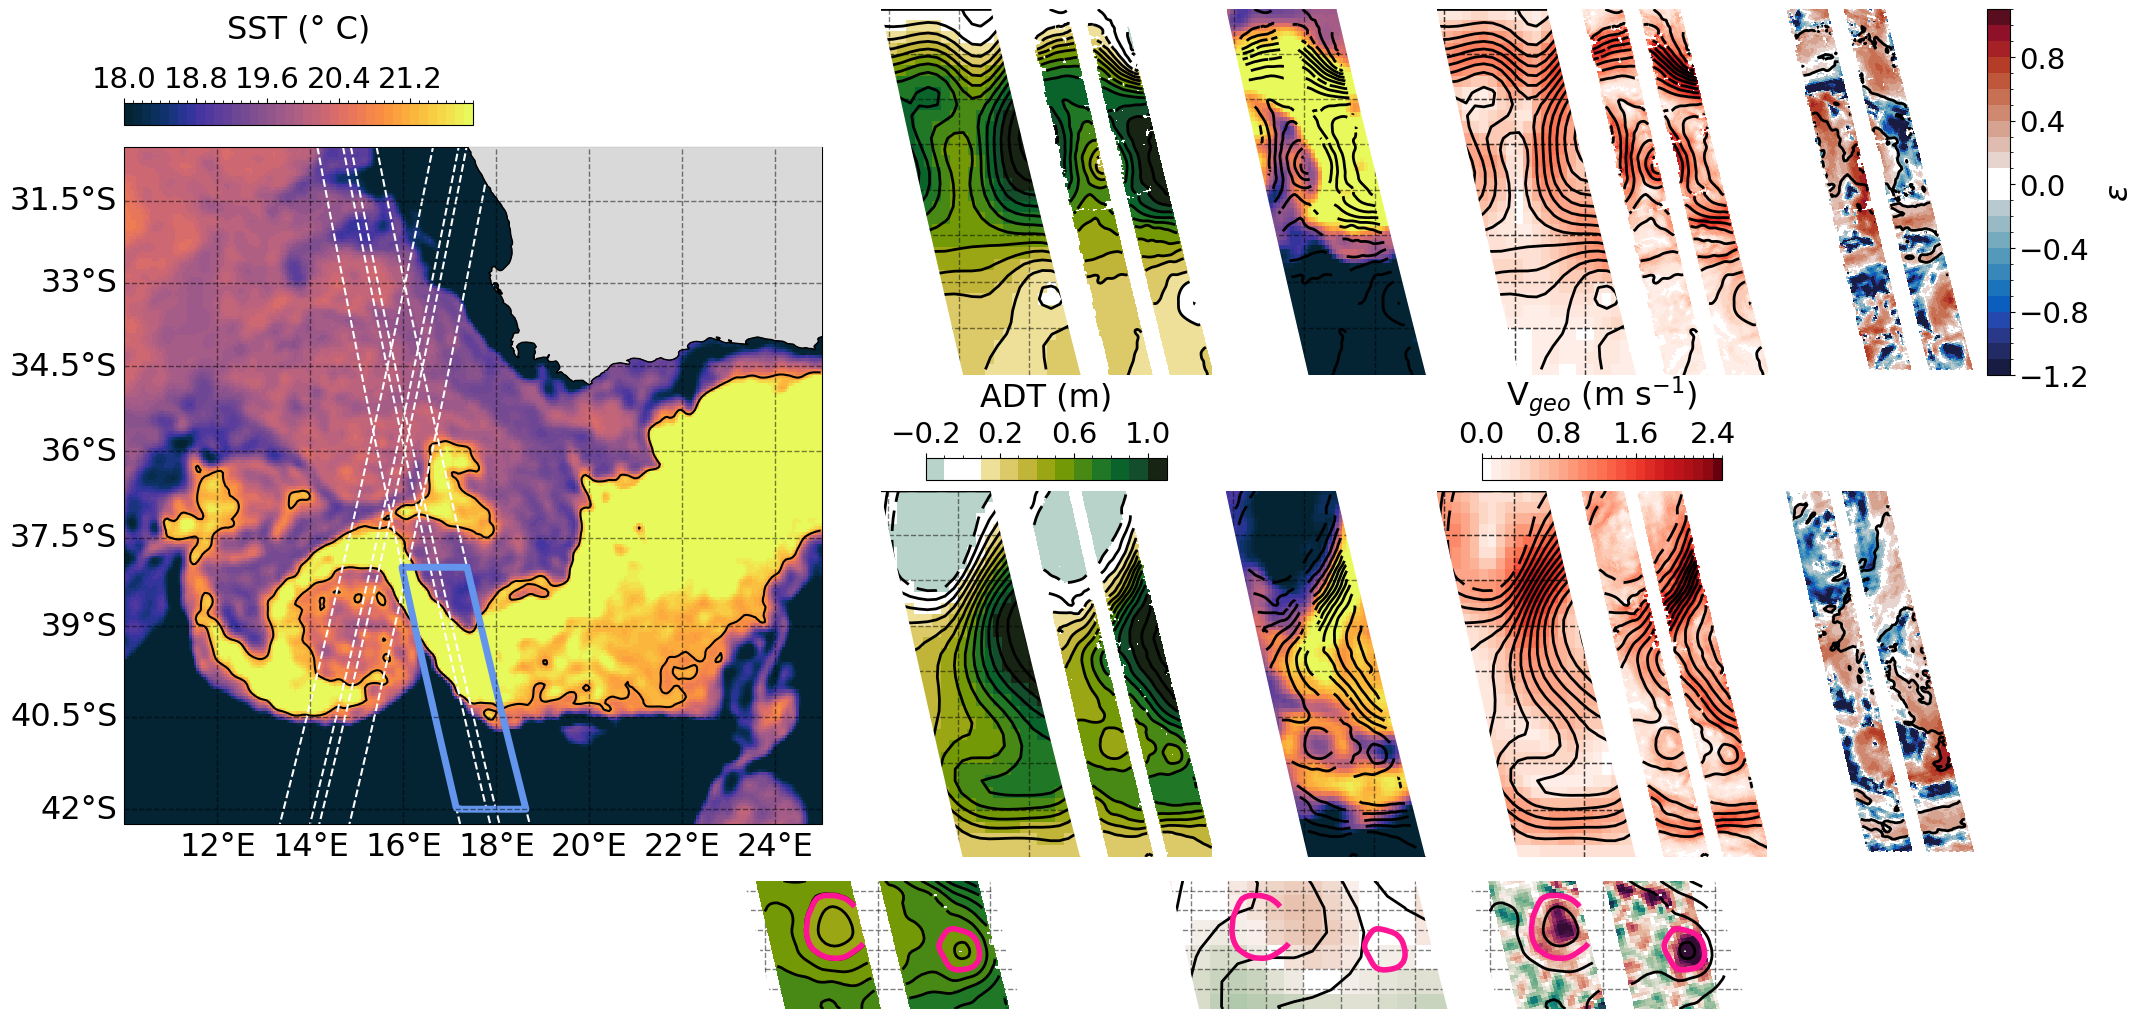

In [238]:
fig = plt.figure(figsize=(9,11))

###Plot regional SST map
ds_sat = ds_sst.isel(time=d1)

    #Projection
proj = ccrs.Mercator(central_longitude= 18.85, min_latitude=-45, max_latitude=-30.5)
crs = ccrs.PlateCarree()
pos_west, pos_east, pos_south, pos_north  = 10, 25, -42, -30.5  #Reset the area
extent = [pos_west, pos_east, pos_south, pos_north]
cartmap = proj,crs,extent

    #Set axe
ax0 = fig.add_subplot(1, 1, 1,projection=proj, zorder=8)
ax0.add_feature(cfeature.LAND,linewidth=0.5,zorder=4, edgecolor='black', facecolor=(0.85,0.85,0.85))
ax0.coastlines(resolution='10m', color='k', linestyle='-', alpha=1,zorder=5)
ax0.set_extent(extent)
map_grid = ax0.gridlines(linewidth=1, color='black', alpha=0.5, linestyle='--', draw_labels=True,zorder=6)
map_grid.xlabel_style = {'size': ft}
map_grid.ylabel_style = {'size': ft}
map_grid.top_labels = False
map_grid.right_labels = False

    #Plot SST map
im = ax0.pcolormesh(ds_sat.longitude, ds_sat.latitude, ds_sat.analysed_sst-273.15, cmap=cmap_SST, norm=norm_SST, transform=crs)
ax0.contour(ds_sat.longitude, ds_sat.latitude, ds_sat.analysed_sst-273.15, colors='k', levels=[21], transform=crs)

    #Add SWOT tracks
swot_1 = xr.open_dataset(file_swot[0])
swot_2 = xr.open_dataset(file_swot[1])

for t in [4,30,38,64]:
    ax0.plot(swot_1.longitude[:,t], swot_1.latitude[:,t], 'w--', transform=crs)
    ax0.plot(swot_2.longitude[:,t], swot_2.latitude[:,t], 'w--', transform=crs)
    
    #Add colorbar
pos0 = ax0.get_position()
label_colorbar = 'SST (° C)'
cax = fig.add_axes([pos0.x0, pos0.y0+pos0.height+0.02, pos0.width/2, 0.02])
cbar = fig.colorbar(im,cax=cax, orientation='horizontal',ticks=Tinc_SST[::8])
cbar.set_label(label_colorbar, fontsize=ft, labelpad=20)
cbar.ax.tick_params(labelsize=ft-2)
cax.xaxis.set_label_position('top')
cax.xaxis.set_ticks_position('top')




###Plot zoom 1
date_str = list_days[date_zoom_1].astype('datetime64[D]')
date_datetime = date_str.astype(datetime)
file_swot_zoom_1 = [x for x in glob(swot_dir+'*'+'016'+'*'+date_datetime.strftime("%Y%m%d")+'*.nc')][0]

    #Reset projection
proj = ccrs.Mercator(central_longitude=18.6, min_latitude=-42, max_latitude=-38)
crs = ccrs.PlateCarree()
pos_west, pos_east, pos_south, pos_north  = 15.9, 20.6, -42, -38 
extent = [pos_west, pos_east, pos_south, pos_north]
cartmap = proj, crs, extent
    
    #Add location of the zooms on the regional SST map
swot_zoom_1 = xr.open_dataset(file_swot_zoom_1)
id_select = np.unique(np.where((swot_zoom_1.longitude>pos_west) & (swot_zoom_1.longitude<pos_east) & (swot_zoom_1.latitude>pos_south) & (swot_zoom_1.latitude<pos_north))[0])
poly_right_lon = np.concatenate((swot_zoom_1.longitude.data[id_select][0, 4:65], swot_zoom_1.longitude.data[id_select][1:227, 64], swot_zoom_1.longitude.data[id_select][-1, 63:3:-1], swot_zoom_1.longitude.data[id_select][-2:13:-1, 4]))
poly_right_lat = np.concatenate((-38*np.ones_like(swot_zoom_1.longitude.data[id_select][0, 4:65]), swot_zoom_1.latitude.data[id_select][1:227, 64], -42*np.ones_like(swot_zoom_1.longitude.data[id_select][-1, 63:3:-1]), swot_zoom_1.latitude.data[id_select][-2:13:-1, 4]))
ax0.plot(poly_right_lon,poly_right_lat, 'cornflowerblue', linewidth=5, transform=crs);

    ##Plot SSH (DUACS & SWOT)

        #Set axe
hh = pos0.height+0.05
ax2 = fig.add_axes([pos0.x0+pos0.width+0.05, pos0.y0+hh/2+0.075, 0.4, hh/2],projection=proj)
ax2.set_extent(extent)
map_grid=ax2.gridlines(linewidth=1, color='black', alpha=0.5, linestyle='--', draw_labels=False, zorder=6)
ax2.set_frame_on(False)
    
        #Plot DUACS
ds_sat = ds_ssh.isel(time=date_zoom_1)
im = ax2.pcolormesh(ds_sat.longitude, ds_sat.latitude, ds_sat.adt,cmap=cmap_SSH, norm=norm_SSH, transform=crs)
ax2.contour(ds_sat.longitude, ds_sat.latitude, ds_sat.adt, levels=np.arange(-0.1,1.6, 0.1), colors='k', linewidths=2, transform=crs, zorder=15)

        #Mask data outside SWOT tracks

            #Define the patches
lon_array_right = np.concatenate((swot_zoom_1.longitude[id_select, 0], [20.6, 20.6, swot_zoom_1.longitude[id_select[0], 0]]))
lat_array_right = np.concatenate((swot_zoom_1.latitude[id_select, 0],[swot_zoom_1.latitude[id_select[-1], 0], swot_zoom_1.latitude[id_select[0], 0], swot_zoom_1.latitude[id_select[0], 0]]))
right = np.column_stack((lon_array_right, lat_array_right)) # Reshape coordinates
patch_right = Polygon(right) # create polygon
lon_array_left = np.concatenate((swot_zoom_1.longitude[id_select, -1],[14, 14, swot_zoom_1.longitude[id_select[0], -1]]))
lat_array_left = np.concatenate((swot_zoom_1.latitude[id_select, -1],[swot_zoom_1.latitude[id_select[-1], -1], swot_zoom_1.latitude[id_select[0], -1], swot_zoom_1.latitude[id_select[0], -1]]))
left = np.column_stack((lon_array_left, lat_array_left)) # Reshape coordinates
patch_left = Polygon(left) # create polygon

            #Plot the patches
ax2.add_geometries([patch_right], crs=crs, facecolor='w',edgecolor='w', zorder=30)
ax2.add_geometries([patch_left], crs=crs, facecolor='w',edgecolor='w', zorder=30)

        #Plot SWOT
field = swot_zoom_1.ssha_filtered.data[id_select] + swot_zoom_1.mdt.data[id_select]
im = ax2.pcolormesh(swot_zoom_1.longitude.data[id_select]+2, swot_zoom_1.latitude.data[id_select], field, cmap=cmap_SSH, norm=norm_SSH, transform=crs, zorder=40)
ax2.contour(swot_zoom_1.longitude.data[id_select]+2, swot_zoom_1.latitude.data[id_select], field, levels=np.arange(-0.1,1.6, 0.1), colors='k', linewidths=2, transform=crs, zorder=41)

    ##Plot SST 

        #Set axe
pos1 = ax2.get_position()
ax3 = fig.add_axes([pos1.x0+pos1.width, pos0.y0+hh/2+0.075, 0.4, hh/2],projection=proj, zorder=2)
ax3.set_extent(extent)
map_grid=ax3.gridlines(linewidth=1, color='black', alpha=0.5, linestyle='--', draw_labels=False, zorder=6)
ax3.set_frame_on(False)

        #Plot
ds_sat = ds_sst.isel(time=date_zoom_1)
im = ax3.pcolormesh(ds_sat.longitude,ds_sat.latitude,ds_sat.analysed_sst-273.15,cmap=cmap_SST, norm=norm_SST,transform=crs)
ax3.contour(tem.longitude.data[id_select], tem.latitude.data[id_select], field, levels=np.arange(-0.1,1.6, 0.1), colors='k', linewidths=2, transform=crs, zorder=11)

        #Mask data outside SWOT tracks
ax3.add_geometries([patch_right], crs=crs, facecolor='w',edgecolor='w', zorder=30)
ax3.add_geometries([patch_left], crs=crs, facecolor='w',edgecolor='w', zorder=30)

    ##Plot Speed (DUACS & SWOT)

        #Set axe
pos3 = ax3.get_position()
ax4 = fig.add_axes([pos3.x0+ pos3.width-0.15, pos0.y0+hh/2+0.075, 0.4, hh/2], projection=proj, zorder=2)
ax4.set_extent(extent)
map_grid=ax4.gridlines(linewidth=1, color='black', alpha=0.5, linestyle='--', draw_labels=False, zorder=6)
ax4.set_frame_on(False)

        #Plot DUACS
ds_sat = ds_ssh.isel(time=date_zoom_1)
im = ax4.pcolormesh(ds_sat.longitude,ds_sat.latitude,np.sqrt(ds_sat.ugos**2 + ds_sat.vgos**2), cmap=cmap_V, norm=norm_V, transform=crs)
ax4.contour(ds_sat.longitude, ds_sat.latitude, ds_sat.adt, levels=np.arange(-0.1,1.6, 0.1), colors='k', linewidths=2, transform=crs, zorder=15)

        #Mask data outside SWOT tracks
ax4.add_geometries([patch_right], crs=crs, facecolor='w',edgecolor='w', zorder=30)
ax4.add_geometries([patch_left], crs=crs, facecolor='w',edgecolor='w', zorder=30)
        
        #Plot SWOT
speed_swot = np.sqrt(swot_zoom_1.ugos_filtered.data[id_select]**2 + swot_zoom_1.vgos_filtered.data[id_select]**2)
ax4.pcolormesh(swot_zoom_1.longitude.data[id_select]+2, swot_zoom_1.latitude.data[id_select], speed_swot, cmap=cmap_V, norm=norm_V, transform=crs, zorder=40)
ax4.contour(swot_zoom_1.longitude.data[id_select]+2, swot_zoom_1.latitude.data[id_select], field, levels=np.arange(-0.1,1.6, 0.1), colors='k', linewidths=2, transform=crs, zorder=41)

    ##Plot normalized difference (epsilon)
    
        #Compute epsilon
ds_sat = ds_ssh.isel(time=date_zoom_1).sel(longitude=slice(15,19.5), latitude=slice(-43,-37))

x_grid, y_grid = np.meshgrid(ds_sat.longitude, ds_sat.latitude)
x_sat, y_sat = np.squeeze(x_grid.reshape(-1,1)), np.squeeze(y_grid.reshape(-1,1))
x_swot, y_swot = np.squeeze(swot_zoom_1.longitude.data[id_select].reshape(-1,1)), np.squeeze(swot_zoom_1.latitude.data[id_select].reshape(-1,1))

field_gridded = np.squeeze(np.sqrt(ds_sat.ugos**2 + ds_sat.vgos**2).data.reshape(-1,1))
field_interpolate = griddata((x_sat, y_sat), field_gridded, (x_swot, y_swot))
field_swot = np.squeeze(speed_swot.reshape(-1,1))
epsilon_1D = (field_swot-field_interpolate)/field_swot

        #Set axe
pos4 = ax4.get_position()
ax6 = fig.add_axes([pos4.x0+ pos4.width, pos0.y0+hh/2+0.075, 0.4, hh/2], projection=proj, zorder=2)
ax6.set_extent(extent)
map_grid=ax4.gridlines(linewidth=1, color='black', alpha=0.5, linestyle='--', draw_labels=False, zorder=6)
ax6.set_frame_on(False)

        #Plot
im = ax6.pcolormesh(tem.longitude.data[id_select],tem.latitude.data[id_select], epsilon_1D.reshape(len(tem.longitude.data[id_select][:,0]),69), cmap=cmap_eps, norm=norm_eps, transform=crs)

        #Add speed contour
ax6.contour(swot_zoom_1.longitude.data[id_select], swot_zoom_1.latitude.data[id_select], speed_swot, levels=[1], colors='k', linewidths=2, transform=crs, zorder=11)

        #Add colorbar
pos6=ax6.get_position()
label_colorbar = '$\epsilon$'
cax = fig.add_axes([pos6.x0+pos6.width-0.14, pos6.y0, 0.025, pos6.height])
cbar = fig.colorbar(im,cax=cax, orientation='vertical',ticks=Tinc_eps[::4])
cbar.set_label(label_colorbar, fontsize=ft,labelpad=10)
cbar.ax.tick_params(labelsize=ft-2)




###Plot zoom 2
date_str = list_days[date_zoom_2].astype('datetime64[D]')
date_datetime = date_str.astype(datetime)
file_swot_zoom_2 = [x for x in glob(swot_dir+'*'+'016'+'*'+date_datetime.strftime("%Y%m%d")+'*.nc')][0]

    ##Plot SSH (DUACS & SWOT)

        #Set axe
pos1 = ax2.get_position()
ax2 = fig.add_axes([pos1.x0-0.017, pos0.y0-0.03, 0.4, hh/2],projection=proj)
ax2.set_extent(extent)
map_grid=ax2.gridlines(linewidth=1, color='black', alpha=0.5, linestyle='--', draw_labels=False, zorder=6)
ax2.set_frame_on(False)
    
        #Plot DUACS
ds_sat = ds_ssh.isel(time=date_zoom_2)
im = ax2.pcolormesh(ds_sat.longitude, ds_sat.latitude, ds_sat.adt,cmap=cmap_SSH, norm=norm_SSH, transform=crs)
ax2.contour(ds_sat.longitude, ds_sat.latitude, ds_sat.adt, levels=np.arange(-0.1,1.6, 0.1), colors='k', linewidths=2, transform=crs, zorder=15)

        #Mask data outside SWOT tracks
ax2.add_geometries([patch_right], crs=crs, facecolor='w',edgecolor='w', zorder=30)
ax2.add_geometries([patch_left], crs=crs, facecolor='w',edgecolor='w', zorder=30)

        #Plot SWOT
swot_zoom_2 = xr.open_dataset(file_swot_zoom_2)
field = swot_zoom_2.ssha_filtered.data[id_select] + swot_zoom_2.mdt.data[id_select]
im = ax2.pcolormesh(swot_zoom_2.longitude.data[id_select]+2, swot_zoom_2.latitude.data[id_select], field, cmap=cmap_SSH, norm=norm_SSH, transform=crs, zorder=40)
ax2.contour(swot_zoom_2.longitude.data[id_select]+2, swot_zoom_2.latitude.data[id_select], field, levels=np.arange(-0.1,1.6, 0.1), colors='k', linewidths=2, transform=crs, zorder=41)

        #Add Colorbar
pos2 = ax2.get_position()
label_colorbar = 'ADT (m)'
cax = fig.add_axes([pos2.x0+0.05, pos2.y0+pos2.height+0.01, pos2.width-0.1, 0.02])
cbar = fig.colorbar(im,cax=cax, orientation='horizontal', ticks=Tinc_SSH[::4])
cbar.set_label(label_colorbar, fontsize=ft, labelpad=10)
cax.xaxis.set_label_position('top')
cax.xaxis.set_ticks_position('top')
cbar.ax.tick_params(labelsize=ft-2)

    ##Plot SST
    
        #Set axe
ax3 = fig.add_axes([pos2.x0+ pos2.width, pos0.y0-0.03, 0.4, hh/2], projection=proj, zorder=2)
ax3.set_extent(extent)
map_grid=ax3.gridlines(linewidth=1, color='black', alpha=0.5, linestyle='--', draw_labels=False, zorder=6)
ax3.set_frame_on(False)

        #Plot
ds_sat = ds_sst.isel(time=date_zoom_2)
im = ax3.pcolormesh(ds_sat.longitude,ds_sat.latitude,ds_sat.analysed_sst-273.15,cmap=cmap_SST, norm=norm_SST,transform=crs)
ax3.contour(swot_zoom_2.longitude.data[id_select], swot_zoom_2.latitude.data[id_select], field, levels=np.arange(-0.1,1.6, 0.1), colors='k', linewidths=2,transform=crs, zorder=11)

        #Mask data outside SWOT tracks
ax3.add_geometries([patch_right], crs=crs, facecolor='w',edgecolor='w', zorder=30)
ax3.add_geometries([patch_left], crs=crs, facecolor='w',edgecolor='w', zorder=30)

    ##Plot Speed (DUACS & SWOT)

        #Set axe
pos3 = ax3.get_position()
ax4 = fig.add_axes([pos3.x0+ pos3.width-0.15, pos0.y0-0.03, 0.4, hh/2],projection=proj, zorder=2)
ax4.set_extent(extent)
map_grid=ax4.gridlines(linewidth=1, color='black', alpha=0.5, linestyle='--', draw_labels=False,zorder=6)
ax4.set_frame_on(False)

        #Plot DUACS
ds_sat = ds_ssh.isel(time=date_zoom_2)
im = ax4.pcolormesh(ds_sat.longitude,ds_sat.latitude,np.sqrt(ds_sat.ugos**2 + ds_sat.vgos**2), cmap=cmap_V, norm=norm_V, transform=crs)
ax4.contour(ds_sat.longitude, ds_sat.latitude, ds_sat.adt, levels=np.arange(-0.1,1.6, 0.1), colors='k', linewidths=2, transform=crs, zorder=15)

        #Mask data outside SWOT tracks
ax4.add_geometries([patch_right], crs=crs, facecolor='w',edgecolor='w', zorder=30)
ax4.add_geometries([patch_left], crs=crs, facecolor='w',edgecolor='w', zorder=30)
        
        #Plot SWOT
speed_swot = np.sqrt(swot_zoom_2.ugos_filtered.data[id_select]**2 + swot_zoom_2.vgos_filtered.data[id_select]**2)
ax4.pcolormesh(swot_zoom_2.longitude.data[id_select]+2, swot_zoom_2.latitude.data[id_select], speed_swot, cmap=cmap_V, norm=norm_V, transform=crs, zorder=40)
ax4.contour(swot_zoom_2.longitude.data[id_select]+2, swot_zoom_2.latitude.data[id_select], field, levels=np.arange(-0.1,1.6, 0.1), colors='k', linewidths=2, transform=crs, zorder=41)

        #Add Colorbar
pos4 = ax4.get_position()
label_colorbar = 'V$_{geo}$ (m s$^{-1}$)'
cax = fig.add_axes([pos4.x0+0.05, pos4.y0+pos1.height+0.01, pos4.width-0.1, 0.02])
cbar = fig.colorbar(im,cax=cax, orientation='horizontal',ticks=Tinc_V[::8])
cbar.set_label(label_colorbar, fontsize=ft,labelpad=10)
cax.xaxis.set_label_position('top')
cax.xaxis.set_ticks_position('top')
cbar.ax.tick_params(labelsize=ft-2)

    ##Plot normalized difference (epsilon)
    
        #Compute epsilon
ds_sat = ds_ssh.isel(time=date_zoom_2).sel(longitude=slice(15,19.5), latitude=slice(-43,-37))

x_grid, y_grid = np.meshgrid(ds_sat.longitude, ds_sat.latitude)
x_sat, y_sat = np.squeeze(x_grid.reshape(-1,1)), np.squeeze(y_grid.reshape(-1,1))
x_swot, y_swot = np.squeeze(swot_zoom_2.longitude.data[id_select].reshape(-1,1)), np.squeeze(swot_zoom_2.latitude.data[id_select].reshape(-1,1))

field_gridded = np.squeeze(np.sqrt(ds_sat.ugos**2 + ds_sat.vgos**2).data.reshape(-1,1))
field_interpolate = griddata((x_sat, y_sat), field_gridded, (x_swot, y_swot))
field_swot = np.squeeze(speed_swot.reshape(-1,1))
epsilon_1D = (field_swot-field_interpolate)/field_swot

        #Set axe
ax6 = fig.add_axes([pos4.x0+ pos4.width, pos0.y0-0.03, 0.4, hh/2],projection=proj, zorder=2)
ax6.set_extent(extent)
map_grid=ax4.gridlines(linewidth=1, color='black', alpha=0.5, linestyle='--', draw_labels=False,zorder=6)
ax6.set_frame_on(False)

        #Plot
im = ax6.pcolormesh(tem.longitude.data[id_select],tem.latitude.data[id_select], epsilon_1D.reshape(len(tem.longitude.data[id_select][:,0]),69), cmap=cmap_eps, norm=norm_eps, transform=crs)

        #Add speed contour
ax6.contour(swot_zoom_2.longitude.data[id_select], swot_zoom_2.latitude.data[id_select], speed_swot, levels=[1], colors='k', linewidths=2, transform=crs, zorder=11)



##Add zoom eddies

    #Reset projection
proj = ccrs.Mercator(central_longitude=17.5,min_latitude=-41.2,max_latitude=-40.55)
crs = ccrs.PlateCarree()
pos_west, pos_east, pos_south, pos_north  = 16.5, 18.5, -41.2, -40.55  #Reset the area
extent=[pos_west, pos_east, pos_south, pos_north]
cartmap = proj,crs,extent

id_select = np.where((swot_zoom_2.longitude>pos_west) & (swot_zoom_2.longitude<pos_east) & (swot_zoom_2.latitude>pos_south) & (swot_zoom_2.latitude<pos_north))[0]

    #Plot ADT
    
        #Set axe
ax7 = fig.add_axes([pos2.x0-0.17, pos0.y0-0.26, hh/2,0.3],projection=proj, zorder=2)
ax7.set_extent(extent)
map_grid=ax7.gridlines(linewidth=1, color='black', alpha=0.5, linestyle='--', draw_labels=False,zorder=6)
ax7.set_frame_on(False)

        #Plot
field = swot_zoom_2.ssha_filtered.data[id_select] + swot_zoom_2.mdt.data[id_select]
im = ax7.pcolormesh(swot_zoom_2.longitude.data[id_select], swot_zoom_2.latitude.data[id_select], field, cmap=cmap_SSH, norm=norm_SSH,transform=crs, zorder=40)
ax7.contour(swot_zoom_2.longitude.data[id_select], swot_zoom_2.latitude.data[id_select], field, levels=np.arange(-0.1,1.6, 0.05), colors='k', linewidths=2,transform=crs, zorder=41)

        #Add eddy contours
ax7.contour(swot_zoom_2.longitude.data[id_select], swot_zoom_2.latitude.data[id_select], field, levels=[0.495], colors='deeppink', linewidths=4, transform=crs, zorder=41)
ax7.contour(swot_zoom_2.longitude.data[id_select][:,:21], swot_zoom_2.latitude.data[id_select][:,:21], field[:,:21], levels=[0.6], colors='deeppink', linewidths=4, transform=crs, zorder=41)

        #Mask data outside SWOT tracks

            #Define the patches
lon_array_right = np.concatenate((swot_zoom_2.longitude[id_select, 0],[20, 20, swot_zoom_2.longitude[id_select[0], 0]]))
lat_array_right = np.concatenate((swot_zoom_2.latitude[id_select, 0],[swot_zoom_2.latitude[id_select[-1], 0],swot_zoom_2.latitude[id_select[0], 0], swot_zoom_2.latitude[id_select[0], 0]]))
right = np.column_stack((lon_array_right, lat_array_right)) # Reshape coordinates
patch_right = Polygon(right) # create polygon

lon_array_left = np.concatenate((swot_zoom_2.longitude[id_select, -1],[14, 14, swot_zoom_2.longitude[id_select[0],-1]]))
lat_array_left = np.concatenate((swot_zoom_2.latitude[id_select, -1],[swot_zoom_2.latitude[id_select[-1], -1], swot_zoom_2.latitude[id_select[0],-1], swot_zoom_2.latitude[id_select[0], -1]]))
left = np.column_stack((lon_array_left, lat_array_left)) # Reshape coordinates
patch_left = Polygon(left) # create polygon

            #Plot the patches
ax7.add_geometries([patch_right], crs=crs, facecolor='w',edgecolor='w', zorder=30)
ax7.add_geometries([patch_left], crs=crs, facecolor='w',edgecolor='w', zorder=30)

    #Plot Rossby number - DUACS

        #Set axe
pos7 = ax7.get_position()
ax8 = fig.add_axes([pos7.x0 + pos7.width+0.14, pos7.y0, pos7.width, pos7.height],projection=proj, zorder=2)
ax8.set_extent(extent)
map_grid=ax8.gridlines(linewidth=1, color='black', alpha=0.5, linestyle='--', draw_labels=False,zorder=6)
ax8.set_frame_on(False)

        #Compute variable
lon_array, lat_array = np.meshgrid(ds_sat.longitude.data,ds_sat.latitude.data)
Rossbyduacs = Rossby_DUACS(ds_sat, lat_array, lon_array)

        #Plot
im = ax8.pcolormesh(ds_sat.longitude.data[1:-1],ds_sat.latitude[1:-1],Rossbyduacs,cmap=cmap_Ro, norm=norm_Ro,transform=crs)
ax8.contour(ds_sat.longitude, ds_sat.latitude, ds_sat.adt, levels=np.arange(-0.1,1.6, 0.1), colors='k', linewidths=2,transform=crs,zorder=15)
ax8.contour(tem.longitude.data[id_select], tem.latitude.data[id_select], field, levels=[0.495], colors='deeppink', linewidths=4,transform=crs, zorder=41)
ax8.contour(tem.longitude.data[id_select][:,:21], tem.latitude.data[id_select][:,:21], field[:,:21], levels=[0.6], colors='deeppink', linewidths=4,transform=crs, zorder=41)

        #Mask data outside SWOT tracks
ax8.add_geometries([patch_right], crs=crs, facecolor='w',edgecolor='w', zorder=30)
ax8.add_geometries([patch_left], crs=crs, facecolor='w',edgecolor='w', zorder=30)

    #Plot Rossby number - SWOT

        #Set axe
pos8 = ax8.get_position()
ax9 = fig.add_axes([pos8.x0+ pos8.width, pos8.y0, pos8.width, pos8.height],projection=proj, zorder=2)
ax9.set_extent(extent)
map_grid=ax9.gridlines(linewidth=1, color='black', alpha=0.5, linestyle='--', draw_labels=False,zorder=6)
ax9.set_frame_on(False)

        #Compute variable
dims = swot_zoom_2.ugos_filtered.dims  
params = dict(derivative = 'dxdy', # Derivative obtained by point difference
            n = 3, 
            min_valid_points = 0.75, # Ratio of valid points to compute the derivative (e.g. 75% valid points are necessary to compute the derivatives, useful to avoid boundary effects)
            second_derivative = 'dxdy' # The second derivative is obtained by point-difference 
)

diag = compute_ocean_diagnostics_from_eta(swot_zoom_2.ssha_filtered+swot_zoom_2.mdt, swot_zoom_2.longitude, swot_zoom_2.latitude, **params)
swot_zoom_2 = swot_zoom_2.assign(zeta = (dims, diag['zeta']))

        #Interpolate NaN
Rossby_raw = swot_zoom_2.zeta.data

idnotnan = np.where(np.isnan(Rossby_raw.reshape(-1,1))==0)[0]
x, y = np.squeeze(swot_zoom_2.longitude.data.reshape(-1,1)), np.squeeze(swot_zoom_2.latitude.data.reshape(-1,1))
Ro_interp = griddata((x[idnotnan], y[idnotnan]), Rossby_raw.reshape(-1,1)[idnotnan], (x, y), method='cubic').reshape(swot_zoom_2.longitude.data.shape)
mask_nan = np.isnan(swot_zoom_2.ssha_filtered.data+swot_zoom_2.mdt.data)
Ro_interp[mask_nan] = np.nan
Ro_interp[:,:8] = np.nan #weird interpolation
swot_zoom_2['Ro_interp'] = xr.DataArray(Ro_interp,dims=('num_lines', 'num_pixels'),coords={'latitude':swot_zoom_2.latitude, 'longitude':swot_zoom_2.longitude})

        #Plot
im = ax9.pcolormesh(swot_zoom_2.longitude, swot_zoom_2.latitude, swot_zoom_2.Ro_interp.data, cmap=cmap_Ro, norm=norm_Ro,transform=crs, zorder=10)
ax9.contour(swot_zoom_2.longitude.data[id_select], swot_zoom_2.latitude.data[id_select], swot_zoom_2.mdt.data[id_select]+swot_zoom_2.ssha_filtered.data[id_select], levels=np.arange(-0.15,1.65, 0.1), colors='k', linewidths=2,transform=crs, zorder=11)
ax9.contour(swot_zoom_2.longitude.data[id_select], swot_zoom_2.latitude.data[id_select], field, levels=[0.495], colors='deeppink', linewidths=4,transform=crs, zorder=41)
ax9.contour(swot_zoom_2.longitude.data[id_select][:,:21], swot_zoom_2.latitude.data[id_select][:,:21], field[:,:21], levels=[0.6], colors='deeppink', linewidths=4,transform=crs, zorder=41)

    #Mask data outside SWOT tracks
ax9.add_geometries([patch_right], crs=crs, facecolor='w',edgecolor='w', zorder=30)
ax9.add_geometries([patch_left], crs=crs, facecolor='w',edgecolor='w', zorder=30)

#fig.savefig(path_save +'Figure_1_submission.png',bbox_inches='tight',dpi=300)


# Analysis Figure 1

## Estimate velocity maximum and size of submesoscale features

### Zoom 2

In [239]:
#Reset around the structure of interest
pos_west,pos_east,pos_south,pos_north  = 15.9,18.75,-41.5,-40.5  #Reset the area
id_select = np.unique(np.where((swot_zoom_2.longitude>pos_west) & (swot_zoom_2.longitude<pos_east) & (swot_zoom_2.latitude>pos_south) & (swot_zoom_2.latitude<pos_north))[0])

#Interpolate DUACS velocities to SWOT grid
ds_sat = ds_ssh.isel(time=date_zoom_2).sel(longitude=slice(pos_west,pos_east), latitude=slice(pos_south,pos_north))
x_grid, y_grid = np.meshgrid(ds_sat.longitude, ds_sat.latitude)
x_sat, y_sat = np.squeeze(x_grid.reshape(-1,1)), np.squeeze(y_grid.reshape(-1,1))
x_swot, y_swot = np.squeeze(swot_zoom_2.longitude.data[id_select].reshape(-1,1)), np.squeeze(swot_zoom_2.latitude.data[id_select].reshape(-1,1))
field_gridded = np.squeeze(np.sqrt(ds_sat.ugos**2 + ds_sat.vgos**2).data.reshape(-1,1))
field_interpolate = griddata((x_sat, y_sat), field_gridded, (x_swot, y_swot))
vel_duacs = field_interpolate.reshape(len(swot_zoom_2.longitude.data[id_select][:,0]),69)

#Interpolate SWOT velocities
x_grid = swot_zoom_2.longitude.data[id_select]
field_swot = np.squeeze(np.sqrt(swot_zoom_2.ugos_filtered.data[id_select]**2 + swot_zoom_2.vgos_filtered.data[id_select]**2))
field_swot_flat = np.squeeze(field_swot.reshape(-1,1))
id_nan = np.where(np.isnan(field_swot_flat)==0)[0]
vel_swot = griddata((x_swot[id_nan], y_swot[id_nan]), field_swot_flat[id_nan], (x_swot, y_swot)).reshape(x_grid.shape)

#Interpolate SWOT ADT field
field = swot_zoom_2.ssha_filtered.data[id_select] + swot_zoom_2.mdt.data[id_select]
field_swot_flat = np.squeeze(field.reshape(-1,1))
id_nan = np.where(np.isnan(field_swot_flat)==0)[0]
adt_swot = griddata((x_swot[id_nan], y_swot[id_nan]), field_swot_flat[id_nan], (x_swot, y_swot)).reshape(x_grid.shape)

#Initialize array to store cells within submesoscale eddies
vel_swot_masked = np.zeros_like(vel_swot)+np.nan
vel_duacs_masked = np.zeros_like(vel_duacs)+np.nan

#### Isolate submesoscale features

Text(0.5, 1.0, 'ADT SWOT - submesoscale isolated')

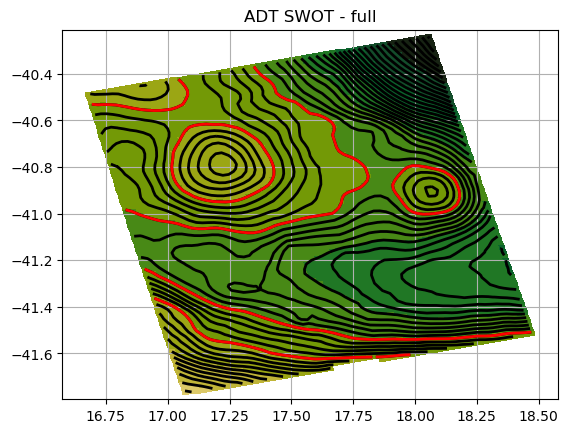

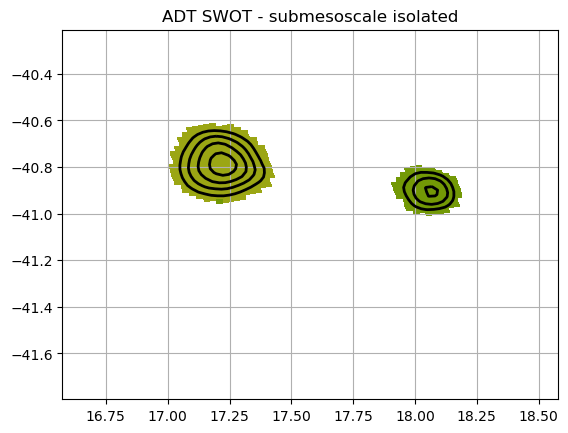

In [240]:
#Plot ADT highliting submesoscale features
plt.figure()
im = plt.pcolormesh(swot_zoom_2.longitude.data[id_select], swot_zoom_2.latitude.data[id_select], adt_swot, cmap=cmap_SSH, norm=norm_SSH)
plt.contour(swot_zoom_2.longitude.data[id_select], swot_zoom_2.latitude.data[id_select], adt_swot, levels=np.arange(0,1.6, 0.02), colors='k', linewidths=2)
plt.contour(swot_zoom_2.longitude.data[id_select], swot_zoom_2.latitude.data[id_select], adt_swot, levels=[0.60], colors='r', linewidths=2)
plt.contour(swot_zoom_2.longitude.data[id_select], swot_zoom_2.latitude.data[id_select], adt_swot, levels=[0.50], colors='r', linewidths=2)
plt.grid()
plt.title('ADT SWOT - full')

#Mask the ADT field
field_modified = np.zeros_like(adt_swot) + np.nan

#Keep submesoscales features unmasked 
mask_ADT_x, mask_ADT_y = np.where((adt_swot<=0.50) & (swot_zoom_2.latitude.data[id_select]<-40.6) & (swot_zoom_2.latitude.data[id_select]>-41))
field_modified[mask_ADT_x,mask_ADT_y]=adt_swot[mask_ADT_x,mask_ADT_y]
vel_swot_masked[mask_ADT_x,mask_ADT_y]=vel_swot[mask_ADT_x,mask_ADT_y]
vel_duacs_masked[mask_ADT_x,mask_ADT_y]=vel_duacs[mask_ADT_x,mask_ADT_y]

mask_ADT_x, mask_ADT_y = np.where((adt_swot<=0.6) & (swot_zoom_2.latitude.data[id_select]<-40.5) & (swot_zoom_2.latitude.data[id_select]>-41.4) & (tem.longitude.data[id_select]>17.85))
field_modified[mask_ADT_x,mask_ADT_y]=adt_swot[mask_ADT_x,mask_ADT_y]
vel_swot_masked[mask_ADT_x,mask_ADT_y]=vel_swot[mask_ADT_x,mask_ADT_y]
vel_duacs_masked[mask_ADT_x,mask_ADT_y]=vel_duacs[mask_ADT_x,mask_ADT_y]

#Plot the isolated features
plt.figure()
im = plt.pcolormesh(swot_zoom_2.longitude.data[id_select], swot_zoom_2.latitude.data[id_select], field_modified, cmap=cmap, norm=norm)
plt.contour(swot_zoom_2.longitude.data[id_select], swot_zoom_2.latitude.data[id_select], field_modified, levels=np.arange(0,1.6, 0.02), colors='k', linewidths=2)
plt.grid()
plt.title('ADT SWOT - submesoscale isolated')

#### Look at the velocity field within the isolated features

Max speed DUACS: 0.44001240701221317
Max speed SWOT: 1.1907310233633792


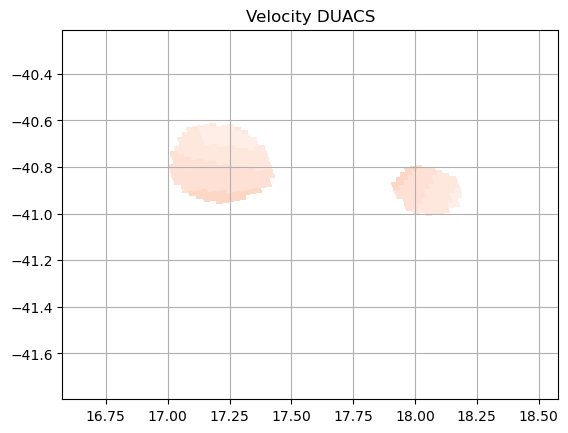

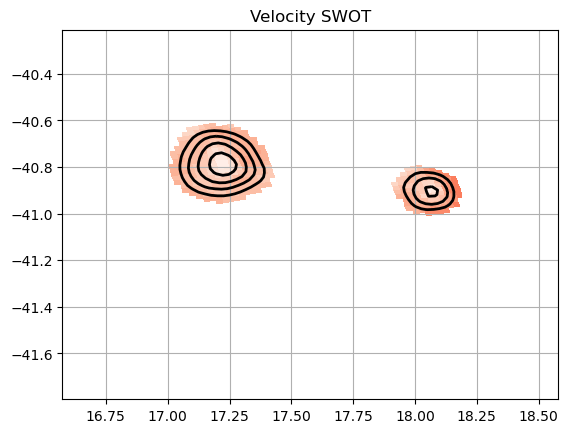

In [241]:
#Plot velocity from DUACS : 
plt.figure()
plt.pcolormesh(swot_zoom_2.longitude.data[id_select], swot_zoom_2.latitude.data[id_select],vel_duacs_masked,cmap=cmap_V, norm=norm_V)
plt.grid()
plt.title('Velocity DUACS')
print('Max speed DUACS: '+ str(np.nanmax(vel_duacs_masked)))

#Plot velocity from SWOT
plt.figure()
plt.pcolormesh(swot_zoom_2.longitude.data[id_select], swot_zoom_2.latitude.data[id_select], vel_swot_masked,cmap=cmap_V, norm=norm_V)
plt.contour(swot_zoom_2.longitude.data[id_select], swot_zoom_2.latitude.data[id_select], field_modified, levels=np.arange(0,1.6, 0.02), colors='k', linewidths=2)
plt.grid()
plt.title('Velocity SWOT')
print('Max speed SWOT: ' + str(np.nanmax(vel_swot_masked)))

#### Estimate submesoscale features diameters

Diameter submesoscale feature n°1: 36.3465718187757
Diameter submesoscale feature n°1: 23.23947223781055


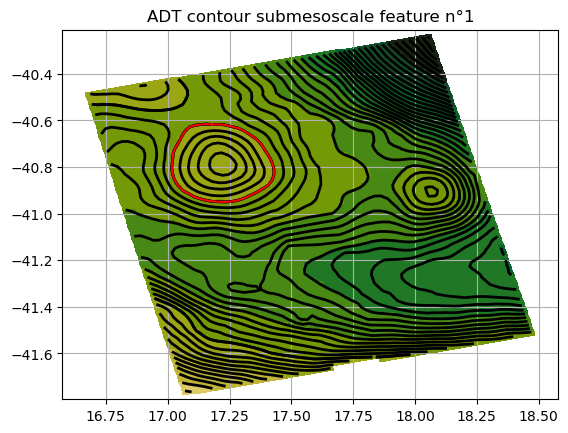

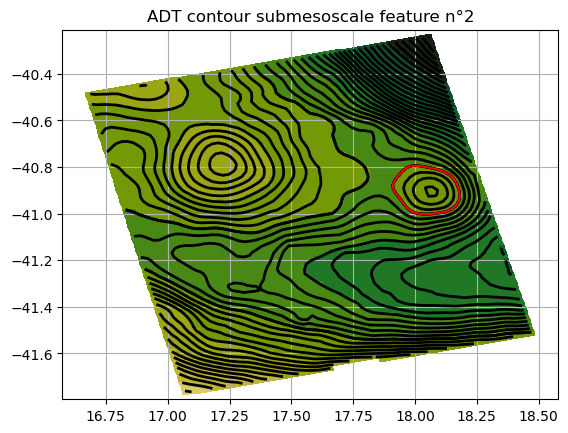

In [242]:
#Submesoscale features n°1
plt.figure()
im = plt.pcolormesh(swot_zoom_2.longitude.data[id_select], swot_zoom_2.latitude.data[id_select], adt_swot, cmap=cmap, norm=norm)
plt.contour(swot_zoom_2.longitude.data[id_select], swot_zoom_2.latitude.data[id_select], adt_swot, levels=np.arange(0,1.6, 0.02), colors='k', linewidths=2)
cs = plt.contour(swot_zoom_2.longitude.data[id_select], swot_zoom_2.latitude.data[id_select], adt_swot, levels=[0.5], colors='k', linewidths=2)
dat0= cs.allsegs[0][3]
plt.plot(dat0[:,0],dat0[:,1], 'r')
plt.grid()
plt.title('ADT contour submesoscale feature n°1')

diam = diameter_from_contour(dat0)

print('Diameter submesoscale feature n°1: ' + str(diam))

#Submesoscale features n°2
plt.figure()
im = plt.pcolormesh(swot_zoom_2.longitude.data[id_select], swot_zoom_2.latitude.data[id_select], adt_swot, cmap=cmap, norm=norm)
plt.contour(swot_zoom_2.longitude.data[id_select], swot_zoom_2.latitude.data[id_select], adt_swot, levels=np.arange(0,1.6, 0.02), colors='k', linewidths=2)
cs = plt.contour(swot_zoom_2.longitude.data[id_select], swot_zoom_2.latitude.data[id_select], adt_swot, levels=[0.6], colors='k', linewidths=2)
dat0= cs.allsegs[0][2]
plt.plot(dat0[:,0],dat0[:,1], 'r')
plt.grid()
plt.title('ADT contour submesoscale feature n°2')

diam = diameter_from_contour(dat0)

print('Diameter submesoscale feature n°1: ' + str(diam))


### Zoom 1

In [243]:
#Reset around the structure of interest
pos_west,pos_east,pos_south,pos_north  = 15.9,18.75,-40.2,-39  #Reset the area
id_select = np.unique(np.where((swot_zoom_1.longitude>pos_west) & (swot_zoom_1.longitude<pos_east) & (swot_zoom_1.latitude>pos_south) & (swot_zoom_1.latitude<pos_north))[0])

#Interpolate DUACS velocities to SWOT grid
ds_sat = ds_ssh.isel(time=date_zoom_1).sel(longitude=slice(pos_west,pos_east), latitude=slice(pos_south,pos_north))
x_grid, y_grid = np.meshgrid(ds_sat.longitude, ds_sat.latitude)
x_sat, y_sat = np.squeeze(x_grid.reshape(-1,1)), np.squeeze(y_grid.reshape(-1,1))
x_swot, y_swot = np.squeeze(swot_zoom_1.longitude.data[id_select].reshape(-1,1)), np.squeeze(swot_zoom_1.latitude.data[id_select].reshape(-1,1))
field_gridded = np.squeeze(np.sqrt(ds_sat.ugos**2 + ds_sat.vgos**2).data.reshape(-1,1))
field_interpolate = griddata((x_sat, y_sat), field_gridded, (x_swot, y_swot))
vel_duacs = field_interpolate.reshape(len(swot_zoom_1.longitude.data[id_select][:,0]),69)

#Interpolate SWOT velocities
x_grid = swot_zoom_1.longitude.data[id_select]
field_swot = np.squeeze(np.sqrt(swot_zoom_1.ugos_filtered.data[id_select]**2 + swot_zoom_1.vgos_filtered.data[id_select]**2))
field_swot_flat = np.squeeze(field_swot.reshape(-1,1))
id_nan = np.where(np.isnan(field_swot_flat)==0)[0]
vel_swot = griddata((x_swot[id_nan], y_swot[id_nan]), field_swot_flat[id_nan], (x_swot, y_swot)).reshape(x_grid.shape)

#Interpolate SWOT ADT field
field = swot_zoom_1.ssha_filtered.data[id_select] + swot_zoom_1.mdt.data[id_select]
field_swot_flat = np.squeeze(field.reshape(-1,1))
id_nan = np.where(np.isnan(field_swot_flat)==0)[0]
adt_swot = griddata((x_swot[id_nan], y_swot[id_nan]), field_swot_flat[id_nan], (x_swot, y_swot)).reshape(x_grid.shape)

#Initialize array to store cells within submesoscale eddies
vel_swot_masked = np.zeros_like(vel_swot)+np.nan
vel_duacs_masked = np.zeros_like(vel_duacs)+np.nan

#### Isolate submesoscale feature

Text(0.5, 1.0, 'ADT SWOT - submesoscale isolated')

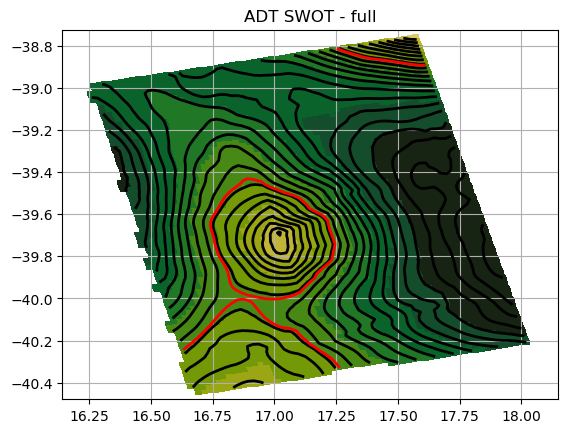

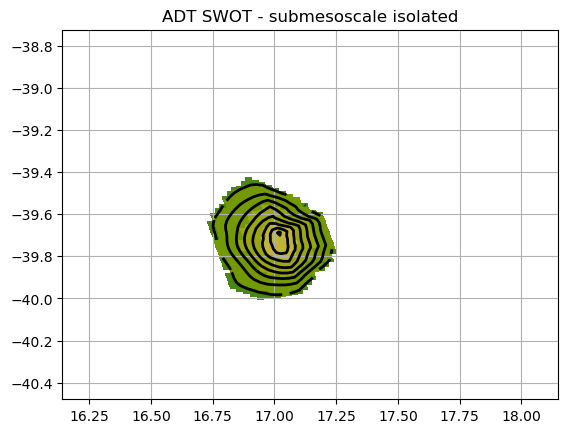

In [244]:
#Plot ADT highliting submesoscale features
plt.figure()
im = plt.pcolormesh(swot_zoom_1.longitude.data[id_select], swot_zoom_1.latitude.data[id_select], adt_swot, cmap=cmap_SSH, norm=norm_SSH)
plt.contour(swot_zoom_1.longitude.data[id_select], swot_zoom_1.latitude.data[id_select], adt_swot, levels=np.arange(0,1.6, 0.04), colors='k', linewidths=2)
plt.contour(swot_zoom_1.longitude.data[id_select], swot_zoom_1.latitude.data[id_select], adt_swot, levels=[0.61], colors='r', linewidths=2)
#plt.contour(swot_zoom_2.longitude.data[id_select], swot_zoom_2.latitude.data[id_select], adt_swot, levels=[0.50], colors='r', linewidths=2)
plt.grid()
plt.title('ADT SWOT - full')

#Mask the ADT field
field_modified = np.zeros_like(adt_swot) + np.nan

#Keep submesoscale feature unmasked 
mask_ADT_x, mask_ADT_y = np.where((adt_swot<=0.61) & (swot_zoom_1.latitude.data[id_select]<-39.4) & (swot_zoom_1.latitude.data[id_select]>-40))
field_modified[mask_ADT_x,mask_ADT_y]=adt_swot[mask_ADT_x,mask_ADT_y]
vel_swot_masked[mask_ADT_x,mask_ADT_y]=vel_swot[mask_ADT_x,mask_ADT_y]
vel_duacs_masked[mask_ADT_x,mask_ADT_y]=vel_duacs[mask_ADT_x,mask_ADT_y]

#Plot the isolated features
plt.figure()
im = plt.pcolormesh(swot_zoom_1.longitude.data[id_select], swot_zoom_1.latitude.data[id_select], field_modified, cmap=cmap, norm=norm)
plt.contour(swot_zoom_1.longitude.data[id_select], swot_zoom_1.latitude.data[id_select], field_modified, levels=np.arange(0,1.6, 0.04), colors='k', linewidths=2)
plt.grid()
plt.title('ADT SWOT - submesoscale isolated')

#### Look at the velocity field within the isolated features

Max speed DUACS: 0.8268192566023622
Max speed SWOT: 1.8915510255719106


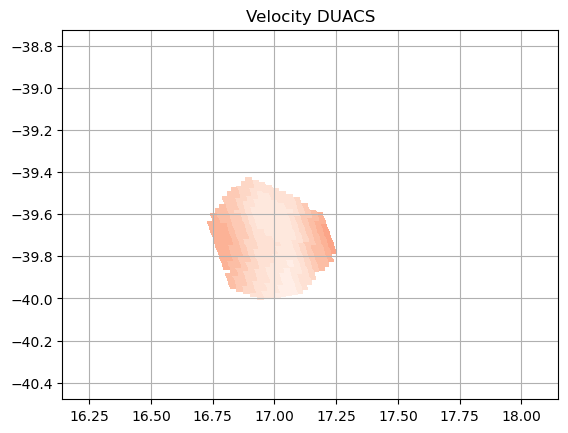

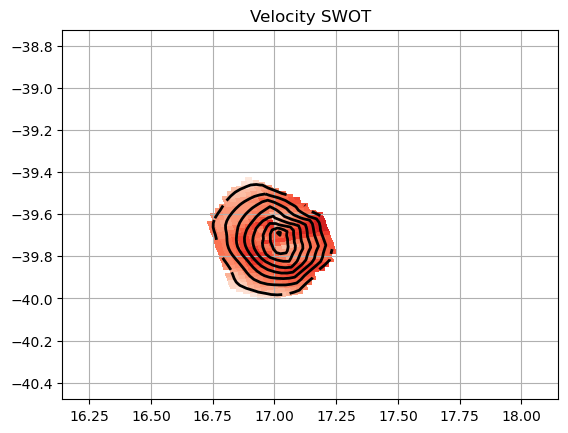

In [245]:
#Plot velocity from DUACS : 
plt.figure()
plt.pcolormesh(swot_zoom_1.longitude.data[id_select], swot_zoom_1.latitude.data[id_select],vel_duacs_masked,cmap=cmap_V, norm=norm_V)
plt.grid()
plt.title('Velocity DUACS')
print('Max speed DUACS: '+ str(np.nanmax(vel_duacs_masked)))

#Plot velocity from SWOT
plt.figure()
plt.pcolormesh(swot_zoom_1.longitude.data[id_select], swot_zoom_1.latitude.data[id_select], vel_swot_masked,cmap=cmap_V, norm=norm_V)
plt.contour(swot_zoom_1.longitude.data[id_select], swot_zoom_1.latitude.data[id_select], field_modified, levels=np.arange(0,1.6, 0.04), colors='k', linewidths=2)
plt.grid()
plt.title('Velocity SWOT')
print('Max speed SWOT: ' + str(np.nanmax(vel_swot_masked)))


#### Estimate submesoscale feature diameter

Diameter submesoscale feature n°1: 54.89227012860703


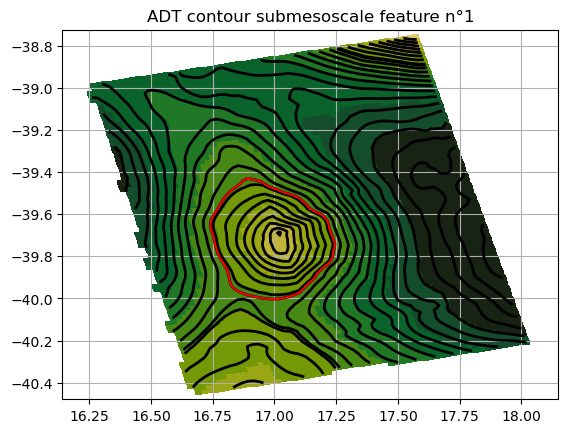

In [246]:
plt.figure()
im = plt.pcolormesh(swot_zoom_1.longitude.data[id_select], swot_zoom_1.latitude.data[id_select], adt_swot, cmap=cmap, norm=norm)
plt.contour(swot_zoom_1.longitude.data[id_select], swot_zoom_1.latitude.data[id_select], adt_swot, levels=np.arange(0,1.6, 0.04), colors='k', linewidths=2)
cs = plt.contour(swot_zoom_1.longitude.data[id_select], swot_zoom_1.latitude.data[id_select], adt_swot, levels=[0.61], colors='k', linewidths=2)
dat0= cs.allsegs[0][2]
plt.plot(dat0[:,0],dat0[:,1], 'r')
plt.grid()
plt.title('ADT contour submesoscale feature n°1')

diam = diameter_from_contour(dat0)

print('Diameter submesoscale feature n°1: ' + str(diam))

## Compare velocities at the Retroflection

Max speed Retroflection DUACS: 1.6766891572381566
Max speed Retroflection SWOT: 3.278069096282139


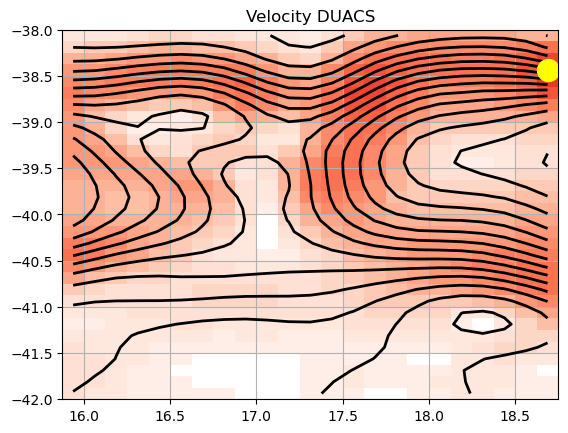

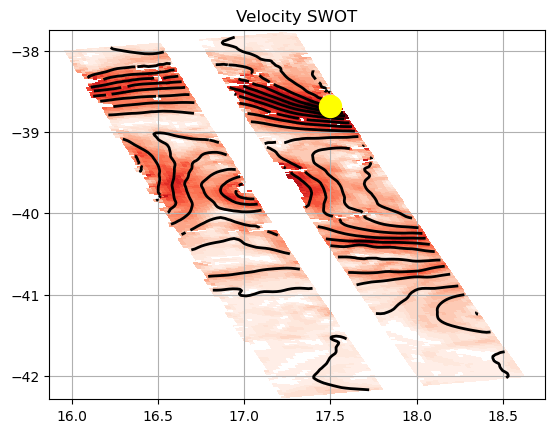

In [248]:
makeZOOM_1 = 1
makeZOOM_2 = 0

if makeZOOM_1:
    data_swot = swot_zoom_1
    date_data = date_zoom_1
elif makeZOOM_2:
    data_swot = swot_zoom_2
    date_data = date_zoom_2
    
pos_west,pos_east,pos_south,pos_north  = 15.9,18.75,-42,-38  #Reset the area
id_select = np.unique(np.where((data_swot.longitude>pos_west) & (data_swot.longitude<pos_east) & (data_swot.latitude>pos_south) & (data_swot.latitude<pos_north))[0])

#Plot Speed DUACS
ds_sat = ds_ssh.isel(time=date_data).sel(longitude=slice(pos_west,pos_east), latitude=slice(pos_south,pos_north))

plt.figure()
im = plt.pcolormesh(ds_sat.longitude,ds_sat.latitude,np.sqrt(ds_sat.ugos**2 + ds_sat.vgos**2),cmap=cmap_V, norm=norm_V)
plt.contour(ds_sat.longitude, ds_sat.latitude, ds_sat.adt, levels=np.arange(-0.1,1.6, 0.1), colors='k', linewidths=2)

#Find index max velocity
row, col = np.unravel_index(np.nanargmax(np.sqrt(ds_sat.ugos.data**2 + ds_sat.vgos.data**2).compute()), ds_sat.ugos.data.shape)

plt.scatter(ds_sat.longitude.data[col], ds_sat.latitude.data[row], 250, color='yellow', zorder=2)
plt.grid()
plt.title('Velocity DUACS')
print('Max speed Retroflection DUACS: ' + str(np.sqrt(ds_sat.ugos.data**2 + ds_sat.vgos.data**2).compute()[row,col]))

#Plot Speed SWOT
plt.figure()
field = data_swot.ssha_filtered.data[id_select] + data_swot.mdt.data[id_select]
speed_swot = np.sqrt(data_swot.ugos_filtered.data[id_select]**2 + data_swot.vgos_filtered.data[id_select]**2)
plt.pcolormesh(data_swot.longitude.data[id_select], data_swot.latitude.data[id_select], speed_swot,cmap=cmap_V, norm=norm_V)
plt.contour(data_swot.longitude.data[id_select], data_swot.latitude.data[id_select], field, levels=np.arange(-0.1,1.6, 0.1), colors='k', linewidths=2)

#Find index max velocity
row, col = np.unravel_index(np.nanargmax(speed_swot), speed_swot.shape)

plt.scatter(data_swot.longitude.data[id_select][row, col], data_swot.latitude.data[id_select][row, col], 250, color='yellow', zorder=2)
plt.grid()
plt.title('Velocity SWOT')
print('Max speed Retroflection SWOT: ' + str(speed_swot[row,col]))

## Espsilon

Median epsilon for SWOT velocities below 1 m s^-1: -0.03067504237254533
Median epsilon for SWOT velocities above 1 m s^-1: 0.25304101199419754


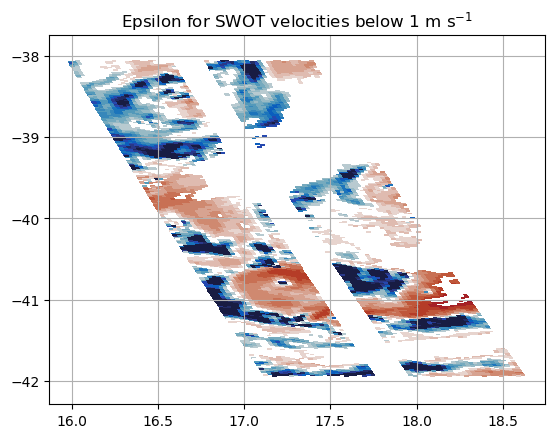

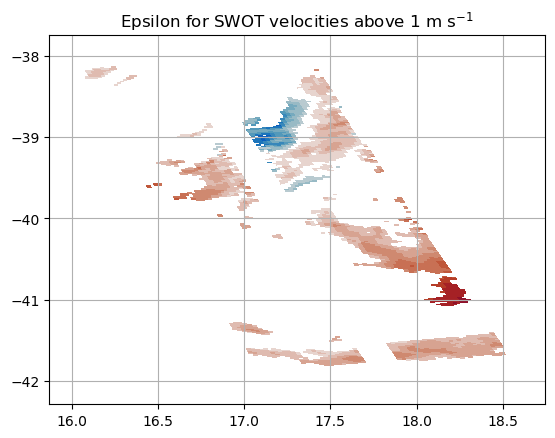

In [250]:
makeZOOM_1 = 0
makeZOOM_2 = 1

if makeZOOM_1:
    data_swot = swot_zoom_1
    date_data = date_zoom_1
elif makeZOOM_2:
    data_swot = swot_zoom_2
    date_data = date_zoom_2
    
#pos_west,pos_east,pos_south,pos_north  = 15.9,18.75,-42,-38  #Reset the area
#id_select = np.unique(np.where((data_swot.longitude>pos_west) & (data_swot.longitude<pos_east) & (data_swot.latitude>pos_south) & (data_swot.latitude<pos_north))[0])

#Plot Speed DUACS
ds_sat = ds_ssh.isel(time=date_data).sel(longitude=slice(pos_west,pos_east), latitude=slice(pos_south,pos_north))

#Interpolate DUACS velocities to SWOT grid
x_grid, y_grid = np.meshgrid(ds_sat.longitude, ds_sat.latitude)
x_sat, y_sat = np.squeeze(x_grid.reshape(-1,1)), np.squeeze(y_grid.reshape(-1,1))
x_swot, y_swot = np.squeeze(data_swot.longitude.data[id_select].reshape(-1,1)), np.squeeze(data_swot.latitude.data[id_select].reshape(-1,1))
field_gridded = np.squeeze(np.sqrt(ds_sat.ugos**2 + ds_sat.vgos**2).data.reshape(-1,1))
field_interpolate = griddata((x_sat, y_sat), field_gridded, (x_swot, y_swot))

#Masked SWOT velocities higher than 1 m s^-1
field_swot = np.squeeze(np.sqrt(data_swot.ugos_filtered.data[id_select]**2 + data_swot.vgos_filtered.data[id_select]**2).reshape(-1,1))
mask_epsilon = np.where(field_swot>=1)[0]
field_swot[mask_epsilon] = np.nan
epsilon_1D = (field_swot-field_interpolate)/field_swot

plt.figure()
plt.pcolormesh(data_swot.longitude.data[id_select],data_swot.latitude.data[id_select], epsilon_1D.reshape(len(data_swot.longitude.data[id_select][:,0]),69), cmap=cmap_eps,norm=norm_eps)
plt.grid()
plt.title('Epsilon for SWOT velocities below 1 m s$^{-1}$')
print('Median epsilon for SWOT velocities below 1 m s^-1: ' + str(np.nanmedian(epsilon_1D)))

#Masked SWOT velocities smaller than 1 m s^-1
field_swot = np.squeeze(np.sqrt(data_swot.ugos_filtered.data[id_select]**2 + data_swot.vgos_filtered.data[id_select]**2).reshape(-1,1))
mask_epsilon = np.where(field_swot<1)[0]
field_swot[mask_epsilon] = np.nan
epsilon_1D = (field_swot-field_interpolate)/field_swot

plt.figure()
plt.pcolormesh(data_swot.longitude.data[id_select],data_swot.latitude.data[id_select], epsilon_1D.reshape(len(data_swot.longitude.data[id_select][:,0]),69), cmap=cmap_eps,norm=norm_eps)
plt.grid()
plt.title('Epsilon for SWOT velocities above 1 m s$^{-1}$')
print('Median epsilon for SWOT velocities above 1 m s^-1: ' + str(np.nanmedian(epsilon_1D)))